# Predicción de la dirección del USD/COP

## 1. Introducción

El comportamiento de la tasa de cambio USD/COP es relevante para la economía
colombiana debido a su relación con el comercio exterior, los precios de bienes
importados, las decisiones de inversión y las condiciones financieras.

La tasa de cambio responde a factores tanto internos como internacionales.
Variables como el precio del petróleo, la percepción de riesgo global, el
comportamiento del mercado accionario estadounidense y las tasas de interés
pueden estar relacionadas con sus movimientos.

Este proyecto utiliza herramientas de aprendizaje estadístico para explorar si
la información financiera y macroeconómica disponible en una fecha determinada
contiene información útil para anticipar la dirección futura del USD/COP.

La primera etapa del proyecto se concentra en la adquisición, limpieza,
integración y análisis descriptivo de las variables seleccionadas, así como en la
construcción de una variable objetivo que represente la dirección de la tasa de
cambio a cinco días hábiles.

## 2. Problema de investigación

Los movimientos de la tasa de cambio son difíciles de anticipar debido a la
interacción de múltiples factores económicos y financieros.

Aunque existen variables que teóricamente pueden estar asociadas con el
comportamiento del peso colombiano, no es evidente si la información disponible
en un momento determinado permite anticipar de manera sistemática su dirección
en horizontes cortos.

A partir de este problema se plantea la siguiente pregunta de investigación:

**¿En qué medida la información financiera y macroeconómica disponible hasta una
fecha \(t\) permite anticipar la dirección del USD/COP durante los siguientes
cinco días hábiles?**

El problema se plantea inicialmente como una tarea de clasificación binaria,
donde se busca determinar si la TRM será superior o no cinco días hábiles después
de cada observación.

## 3. Objetivos

### Objetivo general

Evaluar si variables financieras y macroeconómicas disponibles hasta una fecha
determinada contienen información útil para anticipar la dirección del USD/COP
durante los siguientes cinco días hábiles mediante técnicas de aprendizaje
estadístico.

### Objetivos específicos

1. Construir una base histórica integrada del USD/COP y variables financieras y
   macroeconómicas relevantes para el periodo de estudio.

2. Analizar descriptivamente el comportamiento de las series y sus principales
   características estadísticas y temporales.

3. Construir variables derivadas que representen retornos, volatilidad,
   tendencias y cambios recientes en las condiciones financieras.

4. Definir una variable objetivo binaria que represente la dirección futura del
   USD/COP a cinco días hábiles.

5. Explorar asociaciones entre las variables seleccionadas y la dirección futura
   del USD/COP como preparación para la etapa posterior de modelado.

## 4. Fuentes de datos

El estudio utiliza información diaria proveniente de fuentes oficiales y
financieras. Las variables fueron seleccionadas buscando representar factores
cambiarios, monetarios y de condiciones financieras internacionales.

| Variable | Descripción | Fuente |
|---|---|---|
| USD/COP | Tasa Representativa del Mercado, utilizada como variable principal del estudio. | Banco de la República |
| WTI | Precio del petróleo West Texas Intermediate. Se incorpora por la relevancia del petróleo en la economía y exportaciones colombianas. | FRED / U.S. Energy Information Administration |
| VIX | Índice de volatilidad del mercado estadounidense, utilizado como indicador de incertidumbre y aversión al riesgo. | FRED / CBOE |
| SPY | ETF que replica el comportamiento del S&P 500 y se utiliza como proxy del mercado accionario estadounidense. | Yahoo Finance |
| EFFR | Effective Federal Funds Rate, utilizada para representar las condiciones monetarias de Estados Unidos. | FRED |
| Tasa de política monetaria de Colombia | Principal tasa de intervención del Banco de la República. | Banco de la República |
| Treasury 10Y | Rendimiento de los bonos del Tesoro estadounidense a diez años, utilizado como indicador de condiciones financieras de largo plazo. | FRED |
| Diferencial de tasas | Diferencia entre la tasa de política monetaria colombiana y la EFFR. | Elaboración propia |

El periodo de análisis comienza en enero de 2005. Después de evaluar la cobertura
temporal de las diferentes fuentes, el periodo común disponible se extiende hasta
agosto de 2026.

Las fuentes presentan calendarios diferentes. Las series colombianas pueden
contener observaciones durante fines de semana, mientras que las variables de
mercado estadounidense se registran principalmente durante días de negociación.
Por esta razón, posteriormente se construye un calendario común de análisis.

## 5. Configuración del proyecto

### Entorno y rutas

Se cargan las librerías y se localiza la raíz del proyecto antes de definir las rutas de datos. La búsqueda funciona tanto si el notebook se ejecuta desde la carpeta principal como desde `notebooks`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

current_dir = Path.cwd().resolve()
PROJECT_ROOT = next(
    (
        path
        for path in (current_dir, *current_dir.parents)
        if (path / "data" / "raw").exists()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "No se encontró la carpeta data/raw. Ejecute el notebook dentro del proyecto."
    )

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

START_DATE = "2005-01-01"
MAIN_HORIZON = 5

print("Raíz del proyecto:", PROJECT_ROOT)
print("Versión de pandas:", pd.__version__)

Raíz del proyecto: C:\Users\strik\OneDrive\Documentos\Apes\usd-cop-statistical-learning
Versión de pandas: 3.0.5


## 6. Adquisición de datos


### Lectura de series de FRED

Esta función descarga una serie diaria de FRED, normaliza la fecha y convierte sus valores a formato numérico. Así se aplica el mismo procedimiento a WTI, VIX, EFFR y Treasury 10Y.

In [2]:
def download_fred_series(series_id, column_name):
    url = (
        "https://fred.stlouisfed.org/graph/"
        f"fredgraph.csv?id={series_id}"
    )

    df = pd.read_csv(url)

    df.columns = ["date", column_name]

    df["date"] = pd.to_datetime(df["date"])

    df[column_name] = pd.to_numeric(
        df[column_name],
        errors="coerce"
    )

    return df

### 6.1 TRM USD/COP


La Tasa Representativa del Mercado (TRM) se utiliza como variable principal del estudio.
Los datos fueron obtenidos del Banco de la República de Colombia y corresponden a la
tasa COP/USD diaria.

Para el análisis se utiliza el periodo comprendido entre enero de 2005 y septiembre de
2026. Del archivo original se conserva únicamente la fecha y la TRM diaria.

In [3]:
trm_path = DATA_RAW / "graficador_series.xlsx"
TRM_COLUMN = "Tasa Representativa del Mercado (TRM)(Dato diario)"

trm_raw = pd.read_excel(
    trm_path,
    sheet_name="Datos",
    header=0,
)

trm_raw[["Fecha", TRM_COLUMN]].head()

,Fecha,Tasa Representativa del Mercado (TRM)(Dato diario)
0,dd/mm/aaaa,COP/USD
1,01/01/2005,"2.389,75"
2,02/01/2005,"2.389,75"
3,03/01/2005,"2.389,75"
4,04/01/2005,"2.338,84"


### Limpieza de la TRM

Se conservan la fecha y la TRM diaria, se convierten al formato adecuado y se eliminan registros inválidos o duplicados. El resultado se ordena desde enero de 2005 y se guarda como insumo procesado.

In [4]:
trm = trm_raw[["Fecha", TRM_COLUMN]].copy()
trm = trm.rename(columns={"Fecha": "date", TRM_COLUMN: "usdcop"})

trm["date"] = pd.to_datetime(
    trm["date"],
    format="%d/%m/%Y",
    errors="coerce",
)

trm["usdcop"] = (
    trm["usdcop"]
    .astype(str)
    .str.replace(".", "", regex=False)
    .str.replace(",", ".", regex=False)
)
trm["usdcop"] = pd.to_numeric(trm["usdcop"], errors="coerce")

trm = (
    trm
    .dropna(subset=["date", "usdcop"])
    .drop_duplicates(subset="date")
    .sort_values("date")
    .reset_index(drop=True)
)
trm = trm[trm["date"] >= START_DATE].copy()

trm.to_csv(DATA_PROCESSED / "trm_clean.csv", index=False)
display(trm.head(), trm.tail())

,date,usdcop
0,2005-01-01,"2,389.7500"
1,2005-01-02,"2,389.7500"
2,2005-01-03,"2,389.7500"
3,2005-01-04,"2,338.8400"
4,2005-01-05,"2,315.4500"


,date,usdcop
7911,2026-08-30,"3,202.7900"
7912,2026-08-31,"3,202.7900"
7913,2026-09-01,"3,213.9700"
7914,2026-09-02,"3,184.0000"
7915,2026-09-03,"3,140.5500"


### 6.2 Petróleo WTI

El precio del petróleo West Texas Intermediate (WTI) se incorpora como una
variable externa debido a la relevancia del sector petrolero para la economía
colombiana.

Se utiliza la serie diaria DCOILWTICO, disponible a través de FRED. En etapas
posteriores se evaluará si los movimientos recientes del precio del petróleo
aportan información sobre la dirección futura del USD/COP.

In [5]:
wti = download_fred_series(
    series_id="DCOILWTICO",
    column_name="wti",
)
wti = (
    wti[wti["date"] >= START_DATE]
    .sort_values("date")
    .reset_index(drop=True)
)

wti.to_csv(DATA_RAW / "wti.csv", index=False)
display(wti.head(), wti.tail())

,date,wti
0,2005-01-03,42.1600
1,2005-01-04,43.9600
2,2005-01-05,43.4100
3,2005-01-06,45.5100
4,2005-01-07,45.3200


,date,wti
5667,2026-09-23,93.3800
5668,2026-09-24,95.8800
5669,2026-09-25,85.2300
5670,2026-09-28,99.3700
5671,2026-09-29,96.1600


### 6.3 VIX

El índice de volatilidad VIX se incorpora como una medida de incertidumbre y
aversión al riesgo en los mercados financieros internacionales.

Se utiliza la serie diaria `VIXCLS` disponible en FRED. En etapas posteriores
se evaluará si aumentos en la volatilidad esperada del mercado estadounidense
se encuentran asociados con movimientos posteriores de la tasa USD/COP.

In [6]:
vix = download_fred_series(
    series_id="VIXCLS",
    column_name="vix",
)
vix = (
    vix[vix["date"] >= START_DATE]
    .sort_values("date")
    .reset_index(drop=True)
)

vix.to_csv(DATA_RAW / "vix.csv", index=False)
display(vix.head(), vix.tail())

,date,vix
0,2005-01-03,14.0800
1,2005-01-04,13.9800
2,2005-01-05,14.0900
3,2005-01-06,13.5800
4,2005-01-07,13.4900


,date,vix
5669,2026-09-25,14.8700
5670,2026-09-28,16.0700
5671,2026-09-29,16.0400
5672,2026-09-30,16.3400
5673,2026-10-01,16.3900


### 6.4 Mercado accionario estadounidense (SPY)

El ETF SPDR S&P 500 ETF Trust (SPY) se utiliza como proxy del comportamiento
general del mercado accionario estadounidense.

SPY replica el desempeño del índice S&P 500 y dispone de información histórica
suficiente para cubrir el periodo completo del estudio.

Esta variable se incorpora como indicador de las condiciones globales de
apetito o aversión al riesgo.

In [7]:
spy_raw = yf.download(
    "SPY",
    start=START_DATE,
    auto_adjust=True,
    progress=False,
)

spy = spy_raw[["Close"]].reset_index()
spy.columns = ["date", "spy"]
spy["date"] = pd.to_datetime(spy["date"]).dt.tz_localize(None)
spy["spy"] = pd.to_numeric(spy["spy"], errors="coerce")

spy = (
    spy
    .dropna(subset=["date", "spy"])
    .drop_duplicates(subset="date")
    .sort_values("date")
    .reset_index(drop=True)
)

display(spy.head(), spy.tail())

,date,spy
0,2005-01-03,80.9735
1,2005-01-04,79.9841
2,2005-01-05,79.4322
3,2005-01-06,79.8360
4,2005-01-07,79.7216


,date,spy
5467,2026-09-28,765.6100
5468,2026-09-29,764.2000
5469,2026-09-30,762.6300
5470,2026-10-01,763.9900
5471,2026-10-02,769.6400


### 6.5 Tasa de interés Estados Unidos

La Effective Federal Funds Rate (EFFR) se incorpora como una aproximación a
las condiciones de política monetaria de Estados Unidos.

La tasa de interés estadounidense puede afectar los flujos internacionales de
capital y, por tanto, podría contener información relevante sobre el
comportamiento del USD/COP.

In [8]:
fed_rate = download_fred_series(
    series_id="EFFR",
    column_name="fed_rate"
)

fed_rate = (
    fed_rate[fed_rate["date"] >= START_DATE]
    .sort_values("date")
    .reset_index(drop=True)
)

display(fed_rate.head())
display(fed_rate.tail())

,date,fed_rate
0,2005-01-03,2.3100
1,2005-01-04,2.2500
2,2005-01-05,2.2500
3,2005-01-06,2.2500
4,2005-01-07,2.2400


,date,fed_rate
5669,2026-09-25,3.8800
5670,2026-09-28,3.8800
5671,2026-09-29,3.8800
5672,2026-09-30,3.8800
5673,2026-10-01,3.8800


### 6.6 Tasa de interés Colombia

La tasa de política monetaria del Banco de la República se incorpora como
indicador de las condiciones monetarias internas de Colombia.

Esta tasa corresponde al principal instrumento de intervención de política
monetaria del Banco de la República. Se utiliza la serie diaria publicada por
la entidad.

Posteriormente se construirá el diferencial entre la tasa de política monetaria
colombiana y la tasa efectiva de fondos federales de Estados Unidos, con el fin
de evaluar si las diferencias en condiciones monetarias aportan información
sobre la dirección futura del USD/COP.

In [9]:
col_rate_path = DATA_RAW / "colombia_policy_rate.xlsx"
COL_RATE_COLUMN = "Tasa de política monetaria(Dato diario)"

col_rate_raw = pd.read_excel(
    col_rate_path,
    sheet_name="Datos",
    header=0,
)

col_rate = col_rate_raw[["Fecha", COL_RATE_COLUMN]].copy()
col_rate = col_rate.rename(
    columns={"Fecha": "date", COL_RATE_COLUMN: "col_rate"}
)
col_rate["date"] = pd.to_datetime(
    col_rate["date"],
    format="%d/%m/%Y",
    errors="coerce",
)
col_rate["col_rate"] = (
    col_rate["col_rate"]
    .replace("-", np.nan)
    .astype(str)
    .str.replace(",", ".", regex=False)
)
col_rate["col_rate"] = pd.to_numeric(
    col_rate["col_rate"],
    errors="coerce",
)

col_rate = (
    col_rate
    .dropna(subset=["date", "col_rate"])
    .drop_duplicates(subset="date")
    .sort_values("date")
    .reset_index(drop=True)
)
col_rate = col_rate[col_rate["date"] >= START_DATE].copy()

display(col_rate.head(), col_rate.tail())

,date,col_rate
0,2005-01-01,6.5000
1,2005-01-02,6.5000
2,2005-01-03,6.5000
3,2005-01-04,6.5000
4,2005-01-05,6.5000


,date,col_rate
7903,2026-08-23,12.0000
7904,2026-08-24,12.0000
7905,2026-08-25,12.0000
7906,2026-08-26,12.0000
7907,2026-08-27,12.0000


### 6.7 Treasury 10Y

El rendimiento de los bonos del Tesoro estadounidense a 10 años se incorpora
como indicador de las condiciones financieras de largo plazo en Estados Unidos.

Se utiliza la serie diaria `DGS10` disponible en FRED.

In [10]:
us10y = download_fred_series(
    series_id="DGS10",
    column_name="us10y"
)

us10y = (
    us10y[us10y["date"] >= START_DATE]
    .sort_values("date")
    .reset_index(drop=True)
)

display(us10y.head())
display(us10y.tail())

,date,us10y
0,2005-01-03,4.2300
1,2005-01-04,4.2900
2,2005-01-05,4.2900
3,2005-01-06,4.2900
4,2005-01-07,4.2900


,date,us10y
5669,2026-09-25,5.1700
5670,2026-09-28,5.2400
5671,2026-09-29,5.2600
5672,2026-09-30,5.2900
5673,2026-10-01,5.2400


## 7. Calidad de datos

Antes de integrar las fuentes se revisan su cobertura temporal, los valores faltantes, las fechas duplicadas y las diferencias de calendario. Estas comprobaciones permiten distinguir problemas de registro de ausencias normales por festivos o días sin negociación.

### 7.1 Cobertura, faltantes y duplicados

Se resume la fecha inicial y final de cada serie, su número de observaciones y la proporción de datos faltantes. También se comprueba que cada fuente tenga como máximo un registro por fecha.

In [11]:
datasets = {
    "TRM USD/COP": trm,
    "WTI": wti,
    "VIX": vix,
    "SPY": spy,
    "EFFR": fed_rate,
    "Tasa Colombia": col_rate,
    "Treasury 10Y": us10y,
}

quality_summary = []
for name, data in datasets.items():
    value_column = next(column for column in data.columns if column != "date")
    missing_count = data[value_column].isna().sum()
    quality_summary.append(
        {
            "serie": name,
            "observaciones": len(data),
            "fecha_inicial": data["date"].min(),
            "fecha_final": data["date"].max(),
            "faltantes": missing_count,
            "porcentaje_faltante": missing_count / len(data) * 100,
            "duplicados": data["date"].duplicated().sum(),
        }
    )

quality_summary = pd.DataFrame(quality_summary)
quality_summary

,serie,observaciones,fecha_inicial,fecha_final,faltantes,porcentaje_faltante,duplicados
0,TRM USD/COP,7916,2005-01-01,2026-09-03,0,0.0000,0
1,WTI,5672,2005-01-03,2026-09-29,346,6.1001,0
2,VIX,5674,2005-01-03,2026-10-01,170,2.9961,0
3,SPY,5472,2005-01-03,2026-10-02,0,0.0000,0
4,EFFR,5674,2005-01-03,2026-10-01,211,3.7187,0
5,Tasa Colombia,7908,2005-01-01,2026-08-27,0,0.0000,0
6,Treasury 10Y,5674,2005-01-03,2026-10-01,232,4.0888,0


Las series internacionales tienen menos observaciones que las colombianas porque siguen calendarios de negociación distintos. Los faltantes de WTI, VIX, EFFR y Treasury 10Y representan entre 3 % y 4 % de sus registros, y ninguna fuente presenta fechas duplicadas.

### 7.2 Periodo común de análisis

El inicio común es la fecha inicial más reciente entre las fuentes y el cierre común es la fecha final más antigua. Este intervalo define el periodo que puede integrarse sin extender artificialmente la cobertura de ninguna serie.

In [12]:
common_start = max(data["date"].min() for data in datasets.values())
common_end = min(data["date"].max() for data in datasets.values())

print("Inicio común:", common_start.date())
print("Fin común:", common_end.date())

Inicio común: 2005-01-03
Fin común: 2026-08-27


### 7.3 Diferencias de calendario

Se compara cada fuente con las fechas de la TRM y se cuentan los registros de fin de semana. Se espera una mayor diferencia en las series internacionales, que no publican datos todos los días del calendario colombiano.

In [13]:
trm_dates = set(trm["date"])

calendar_comparison = pd.DataFrame(
    {
        "serie": [name for name in datasets if name != "TRM USD/COP"],
        "fechas_TRM_no_presentes": [
            len(trm_dates - set(data["date"]))
            for name, data in datasets.items()
            if name != "TRM USD/COP"
        ],
    }
)

weekend_summary = pd.DataFrame(
    {
        "serie": list(datasets),
        "observaciones_fin_semana": [
            data["date"].dt.dayofweek.isin([5, 6]).sum()
            for data in datasets.values()
        ],
    }
)

display(calendar_comparison)
display(weekend_summary)

,serie,fechas_TRM_no_presentes
0,WTI,2262
1,VIX,2262
2,SPY,2464
3,EFFR,2262
4,Tasa Colombia,8
5,Treasury 10Y,2262


,serie,observaciones_fin_semana
0,TRM USD/COP,2262
1,WTI,0
2,VIX,0
3,SPY,0
4,EFFR,0
5,Tasa Colombia,2260
6,Treasury 10Y,0


### 7.4 Resultado de la revisión

Las diferencias encontradas son coherentes con la naturaleza de las fuentes y no se observan duplicados que impidan continuar. El principal reto es alinear los calendarios sin introducir información futura, por lo que la integración se hará sobre fechas de lunes a viernes y con el último valor previamente disponible.

## 8. Integración de las fuentes

Las series se combinan sobre un calendario común de lunes a viernes dentro del periodo compartido. Cuando una fuente no registra un dato nuevo, se conserva únicamente el último valor conocido mediante `forward fill`; no se utiliza `backfill`, porque podría incorporar información publicada después de la fecha analizada.

Este calendario aproxima los días hábiles y no elimina de forma explícita todos los festivos nacionales. La simplificación es suficiente para esta primera entrega y se reconoce como una limitación que podrá refinarse más adelante.

In [14]:
# Calendario común de lunes a viernes
master = pd.DataFrame(
    {
        "date": pd.date_range(
            start=common_start,
            end=common_end,
            freq="B"
        )
    }
)

# Series que se integrarán al dataset maestro
series_to_merge = [
    trm,
    wti,
    vix,
    spy,
    fed_rate,
    col_rate,
    us10y,
]

# Integración por fecha
for series in series_to_merge:
    master = master.merge(
        series,
        on="date",
        how="left"
    )

# Se conserva el último valor previamente conocido
value_columns = [
    "usdcop",
    "wti",
    "vix",
    "spy",
    "fed_rate",
    "col_rate",
    "us10y",
]

master[value_columns] = (
    master[value_columns]
    .ffill()
)

# Diferencial entre tasas de Colombia y Estados Unidos
master["rate_spread"] = (
    master["col_rate"]
    - master["fed_rate"]
)

master.head()

,date,usdcop,wti,vix,spy,fed_rate,col_rate,us10y,rate_spread
0,2005-01-03,"2,389.7500",42.1600,14.0800,80.9735,2.3100,6.5000,4.2300,4.1900
1,2005-01-04,"2,338.8400",43.9600,13.9800,79.9841,2.2500,6.5000,4.2900,4.2500
2,2005-01-05,"2,315.4500",43.4100,14.0900,79.4322,2.2500,6.5000,4.2900,4.2500
3,2005-01-06,"2,344.4500",45.5100,13.5800,79.8360,2.2500,6.5000,4.2900,4.2500
4,2005-01-07,"2,386.6700",45.3200,13.4900,79.7216,2.2400,6.5000,4.2900,4.2600


### 8.1 Validación de la base integrada

Se verifican las dimensiones, el periodo, la ausencia de fechas repetidas, fines de semana y valores faltantes. El resultado esperado es una fila por fecha del calendario común y datos completos después de la propagación hacia adelante.

In [15]:
print("Dimensiones:", master.shape)
print("Periodo:", master["date"].min().date(), "a", master["date"].max().date())
print("Fechas duplicadas:", master["date"].duplicated().sum())
print(
    "Observaciones en fin de semana:",
    master["date"].dt.dayofweek.isin([5, 6]).sum(),
)

display(master.isna().sum().to_frame("faltantes"))
display(master.head(), master.tail())

master.to_csv(DATA_PROCESSED / "master_dataset.csv", index=False)

Dimensiones: (5649, 9)
Periodo: 2005-01-03 a 2026-08-27
Fechas duplicadas: 0
Observaciones en fin de semana: 0


,faltantes
date,0
usdcop,0
wti,0
vix,0
spy,0
fed_rate,0
col_rate,0
us10y,0
rate_spread,0


,date,usdcop,wti,vix,spy,fed_rate,col_rate,us10y,rate_spread
0,2005-01-03,"2,389.7500",42.1600,14.0800,80.9735,2.3100,6.5000,4.2300,4.1900
1,2005-01-04,"2,338.8400",43.9600,13.9800,79.9841,2.2500,6.5000,4.2900,4.2500
2,2005-01-05,"2,315.4500",43.4100,14.0900,79.4322,2.2500,6.5000,4.2900,4.2500
3,2005-01-06,"2,344.4500",45.5100,13.5800,79.8360,2.2500,6.5000,4.2900,4.2500
4,2005-01-07,"2,386.6700",45.3200,13.4900,79.7216,2.2400,6.5000,4.2900,4.2600


,date,usdcop,wti,vix,spy,fed_rate,col_rate,us10y,rate_spread
5644,2026-08-21,"3,062.9600",87.2100,15.1300,763.8232,3.6300,12.0000,4.7400,8.3700
5645,2026-08-24,"3,048.1200",86.3400,15.8500,761.5788,3.6300,12.0000,4.7000,8.3700
5646,2026-08-25,"3,056.5100",83.9000,15.4500,764.0128,3.6300,12.0000,4.6400,8.3700
5647,2026-08-26,"3,081.6700",83.4600,15.2100,764.1824,3.6300,12.0000,4.6600,8.3700
5648,2026-08-27,"3,118.2400",84.8100,14.5100,769.1899,3.6300,12.0000,4.6700,8.3700


### 8.2 Resultado de la integración

La base maestra contiene 5.649 fechas de lunes a viernes entre el 3 de enero de 2005 y el 27 de agosto de 2026, sin duplicados ni faltantes. Reúne la TRM, WTI, VIX, SPY, las tasas de Colombia y Estados Unidos, el Treasury a diez años y el diferencial de tasas.

## 9. Construcción de variables

Las series originales contienen niveles de precios, tasas e indicadores de mercado.
Sin embargo, para un problema predictivo resulta más útil representar sus cambios
recientes, tendencias y volatilidad.

Las variables se construyen utilizando únicamente información disponible hasta
cada fecha. Se consideran horizontes cortos, medios y mensuales aproximados de
1, 5 y 20 días hábiles.

Se evita utilizar transformaciones que incorporen observaciones futuras, ya que
esto produciría fuga de información hacia el modelo.

In [16]:
features = master.copy()

# Retornos recientes del USD/COP
features["usdcop_ret_1d"] = features["usdcop"].pct_change(1)
features["usdcop_ret_5d"] = features["usdcop"].pct_change(5)
features["usdcop_ret_20d"] = features["usdcop"].pct_change(20)

# Volatilidad histórica de los retornos diarios
features["usdcop_vol_5d"] = (
    features["usdcop_ret_1d"]
    .rolling(5)
    .std()
)

features["usdcop_vol_20d"] = (
    features["usdcop_ret_1d"]
    .rolling(20)
    .std()
)

# Medias móviles
features["usdcop_ma_5"] = (
    features["usdcop"]
    .rolling(5)
    .mean()
)

features["usdcop_ma_20"] = (
    features["usdcop"]
    .rolling(20)
    .mean()
)

# Distancia relativa frente a la media móvil de 20 días
features["usdcop_ma_gap"] = (
    features["usdcop"]
    / features["usdcop_ma_20"]
    - 1
)

features[
    [
        "date",
        "usdcop",
        "usdcop_ret_1d",
        "usdcop_ret_5d",
        "usdcop_ret_20d",
        "usdcop_vol_5d",
        "usdcop_vol_20d",
        "usdcop_ma_gap",
    ]
].head(25)

,date,usdcop,usdcop_ret_1d,usdcop_ret_5d,usdcop_ret_20d,usdcop_vol_5d,usdcop_vol_20d,usdcop_ma_gap
0,2005-01-03,"2,389.7500",NaN,NaN,NaN,NaN,NaN,NaN
1,2005-01-04,"2,338.8400",-0.0213,NaN,NaN,NaN,NaN,NaN
2,2005-01-05,"2,315.4500",-0.0100,NaN,NaN,NaN,NaN,NaN
3,2005-01-06,"2,344.4500",0.0125,NaN,NaN,NaN,NaN,NaN
4,2005-01-07,"2,386.6700",0.0180,NaN,NaN,NaN,NaN,NaN
5,2005-01-10,"2,358.5400",-0.0118,-0.0131,NaN,0.0169,NaN,NaN
6,2005-01-11,"2,358.5400",0.0000,0.0084,NaN,0.0133,NaN,NaN
7,2005-01-12,"2,380.9600",0.0095,0.0283,NaN,0.0117,NaN,NaN
8,2005-01-13,"2,358.6400",-0.0094,0.0061,NaN,0.0126,NaN,NaN
9,2005-01-14,"2,340.4200",-0.0077,-0.0194,NaN,0.0087,NaN,NaN


### 9.1 Variables propias del USD/COP

Los retornos de 1, 5 y 20 días representan el comportamiento reciente de la
tasa de cambio en diferentes horizontes.

La desviación estándar móvil de los retornos diarios se utiliza como una medida
de volatilidad histórica.

Finalmente, la distancia entre la TRM y su media móvil de 20 días permite
representar la posición actual de la tasa de cambio respecto a su tendencia
reciente.

In [17]:
# Cambios del petróleo
features["wti_ret_1d"] = features["wti"].pct_change(1)
features["wti_ret_5d"] = features["wti"].pct_change(5)
features["wti_ret_20d"] = features["wti"].pct_change(20)

# Cambios del mercado accionario estadounidense
features["spy_ret_1d"] = features["spy"].pct_change(1)
features["spy_ret_5d"] = features["spy"].pct_change(5)
features["spy_ret_20d"] = features["spy"].pct_change(20)

# Nivel y cambio reciente del VIX
features["vix_change_1d"] = features["vix"].pct_change(1)
features["vix_change_5d"] = features["vix"].pct_change(5)

### 9.2 Variables financieras internacionales

Para WTI y SPY se calculan retornos acumulados de 1, 5 y 20 días, con el objetivo
de representar cambios recientes en el precio del petróleo y en el mercado
accionario estadounidense.

En el caso del VIX se conserva su nivel y se incorporan sus variaciones recientes,
ya que aumentos de este indicador suelen representar cambios en la percepción de
riesgo de los mercados.

In [18]:
# Cambios recientes en las tasas
features["fed_rate_change_5d"] = (
    features["fed_rate"]
    .diff(5)
)

features["col_rate_change_5d"] = (
    features["col_rate"]
    .diff(5)
)

features["us10y_change_5d"] = (
    features["us10y"]
    .diff(5)
)

# Cambio del diferencial de tasas
features["rate_spread_change_5d"] = (
    features["rate_spread"]
    .diff(5)
)

### 9.3 Variables de tasas de interés

Además de los niveles de las tasas de interés, se consideran sus cambios recientes.

El diferencial entre la tasa de política monetaria de Colombia y la tasa efectiva
de fondos federales de Estados Unidos se mantiene como una variable relevante,
ya que representa diferencias en las condiciones monetarias entre ambos países.

También se incorpora el rendimiento del Treasury estadounidense a diez años como
indicador de las condiciones financieras de largo plazo.

### 9.4 Depuración del conjunto de variables

Las ventanas móviles generan faltantes solo al comienzo de la serie, pues aún no existe el historial requerido. Se cuantifican esas ausencias, se eliminan las primeras 20 filas incompletas y se guarda el conjunto de variables listo para construir el target.

In [19]:
feature_missing = (
    features
    .isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("faltantes")
)
display(feature_missing[feature_missing["faltantes"] > 0])

model_data = features.dropna().reset_index(drop=True)

print("Observaciones originales:", len(features))
print("Observaciones utilizables:", len(model_data))
print("Observaciones eliminadas:", len(features) - len(model_data))

model_data.to_csv(DATA_PROCESSED / "features_dataset.csv", index=False)

,faltantes
usdcop_ret_20d,20
wti_ret_20d,20
spy_ret_20d,20
usdcop_vol_20d,20
usdcop_ma_gap,19
usdcop_ma_20,19
vix_change_5d,5
wti_ret_5d,5
spy_ret_5d,5
usdcop_ret_5d,5


Observaciones originales: 5649
Observaciones utilizables: 5629
Observaciones eliminadas: 20


### 9.5 Resultado de la construcción de variables

Se obtuvieron 29 columnas que reúnen niveles, retornos, volatilidad, medias móviles y cambios recientes de WTI, SPY, VIX y tasas. Todas las transformaciones usan información de la fecha actual o del pasado; las 20 observaciones iniciales sin historial suficiente se excluyen antes de crear el target.

## 10. Construcción del target

El objetivo principal del proyecto es anticipar la dirección del USD/COP durante
los siguientes cinco días hábiles.

Para cada fecha \(t\), se calcula el retorno futuro entre el valor actual de la
TRM y su valor cinco observaciones hábiles después:

\[
R_{t,t+5} = \frac{P_{t+5} - P_t}{P_t}
\]

A partir de este retorno se construye una variable binaria:

- `1`: el USD/COP aumenta durante los siguientes cinco días hábiles.
- `0`: el USD/COP permanece igual o disminuye.

A diferencia de las variables predictoras, el target utiliza información futura
de manera intencional, ya que representa precisamente el resultado que se desea
predecir.

In [20]:
target_data = model_data.copy()

# Precio del USD/COP cinco días hábiles adelante
target_data["usdcop_future_5d"] = (
    target_data["usdcop"]
    .shift(-MAIN_HORIZON)
)

# Retorno futuro a cinco días
target_data["future_return_5d"] = (
    target_data["usdcop_future_5d"]
    / target_data["usdcop"]
    - 1
)

# Target binario: 1 si sube, 0 si no sube
target_data["target_5d"] = np.where(
    target_data["future_return_5d"].notna(),
    (target_data["future_return_5d"] > 0).astype(int),
    np.nan
)

target_data[
    [
        "date",
        "usdcop",
        "usdcop_future_5d",
        "future_return_5d",
        "target_5d",
    ]
].tail(10)

,date,usdcop,usdcop_future_5d,future_return_5d,target_5d
5619,2026-08-14,"3,127.5100","3,062.9600",-0.0206,0.0000
5620,2026-08-17,"3,128.6500","3,048.1200",-0.0257,0.0000
5621,2026-08-18,"3,128.6500","3,056.5100",-0.0231,0.0000
5622,2026-08-19,"3,098.7900","3,081.6700",-0.0055,0.0000
5623,2026-08-20,"3,053.4800","3,118.2400",0.0212,1.0000
5624,2026-08-21,"3,062.9600",NaN,NaN,NaN
5625,2026-08-24,"3,048.1200",NaN,NaN,NaN
5626,2026-08-25,"3,056.5100",NaN,NaN,NaN
5627,2026-08-26,"3,081.6700",NaN,NaN,NaN
5628,2026-08-27,"3,118.2400",NaN,NaN,NaN


### 10.1 Definición del problema de clasificación

El problema se plantea como una clasificación binaria de la dirección futura
del USD/COP.

La clase positiva (`target_5d = 1`) representa periodos en los cuales la TRM
es superior cinco días hábiles después. La clase negativa (`target_5d = 0`)
representa periodos en los cuales la TRM es igual o inferior.

Las últimas cinco observaciones no pueden recibir una clase porque no existe
información futura suficiente para calcular el horizonte completo. Estas filas
se excluyen únicamente del conjunto destinado al modelado supervisado.

In [21]:
dataset = (
    target_data
    .dropna(subset=["future_return_5d", "target_5d"])
    .reset_index(drop=True)
)
dataset["target_5d"] = dataset["target_5d"].astype(int)

print("Observaciones antes del target:", len(model_data))
print("Observaciones finales:", len(dataset))
print("Observaciones eliminadas:", len(model_data) - len(dataset))

display(
    dataset[
        ["date", "usdcop", "usdcop_future_5d", "future_return_5d", "target_5d"]
    ].head(10)
)

dataset.to_csv(DATA_PROCESSED / "model_dataset.csv", index=False)

Observaciones antes del target: 5629
Observaciones finales: 5624
Observaciones eliminadas: 5


,date,usdcop,usdcop_future_5d,future_return_5d,target_5d
0,2005-01-31,"2,367.7600","2,361.9200",-0.0025,0
1,2005-02-01,"2,363.7500","2,365.7900",0.0009,1
2,2005-02-02,"2,358.1600","2,364.1600",0.0025,1
3,2005-02-03,"2,364.1300","2,358.6100",-0.0023,0
4,2005-02-04,"2,365.0800","2,344.9400",-0.0085,0
5,2005-02-07,"2,361.9200","2,346.0400",-0.0067,0
6,2005-02-08,"2,365.7900","2,338.2700",-0.0116,0
7,2005-02-09,"2,364.1600","2,330.6200",-0.0142,0
8,2005-02-10,"2,358.6100","2,331.7000",-0.0114,0
9,2005-02-11,"2,344.9400","2,327.4500",-0.0075,0


### 10.3 Conjunto reducido para modelado

Para mantener una primera versión manejable, se seleccionan como máximo 14 predictores y se conserva el dataset completo para comparación. La selección evita niveles redundantes y prioriza retornos, volatilidad, riesgo global y tasas.

In [22]:
reduced_predictors = [
    "usdcop_ret_1d", "usdcop_ret_5d", "usdcop_ret_20d",
    "usdcop_vol_20d",
    "wti_ret_1d", "wti_ret_5d", "wti_ret_20d",
    "vix", "spy_ret_1d", "spy_ret_5d",
    "us10y", "us10y_change_5d",
    "rate_spread", "rate_spread_change_5d",
]

reduced_dataset = dataset[["date", *reduced_predictors, "target_5d"]].copy()
reduced_dataset.to_csv(
    DATA_PROCESSED / "model_dataset_reduced.csv",
    index=False,
)

print("Predictores reducidos:", len(reduced_predictors))
display(reduced_dataset.head())

Predictores reducidos: 14


,date,usdcop_ret_1d,usdcop_ret_5d,usdcop_ret_20d,usdcop_vol_20d,wti_ret_1d,wti_ret_5d,wti_ret_20d,vix,spy_ret_1d,spy_ret_5d,us10y,us10y_change_5d,rate_spread,rate_spread_change_5d,target_5d
0,2005-01-31,-0.0021,-0.0026,-0.0092,0.0092,0.0233,-0.0074,0.1444,12.8200,0.0062,0.0138,4.1400,0.0000,4.0000,-0.2400,0
1,2005-02-01,-0.0017,-0.0030,0.0107,0.0077,-0.0238,-0.0471,0.0714,12.0300,0.0063,0.0174,4.1500,-0.0500,4.1000,-0.1100,1
2,2005-02-02,-0.0024,-0.0050,0.0184,0.0074,-0.0096,-0.0441,0.0746,11.6600,0.0030,0.0174,4.1500,-0.0600,4.2100,0.0400,1
3,2005-02-03,0.0025,-0.0029,0.0084,0.0069,-0.0054,-0.0492,0.0196,11.7900,-0.0026,0.0130,4.1800,-0.0400,4.0100,-0.1000,0
4,2005-02-04,0.0004,-0.0032,-0.0090,0.0055,0.0011,-0.0148,0.0249,11.2100,0.0107,0.0238,4.0900,-0.0700,3.9900,-0.0300,0


### 10.2 Resultado de la construcción del target

Se construyó una variable objetivo binaria basada en la dirección del retorno
del USD/COP durante los cinco días hábiles siguientes.

El target permite transformar el problema de investigación en una tarea de
clasificación supervisada, donde los modelos utilizarán exclusivamente
información disponible hasta la fecha \(t\) para estimar si la TRM será mayor
cinco días hábiles después.

Las últimas cinco observaciones fueron excluidas debido a que no cuentan con
el horizonte futuro completo necesario para calcular la variable objetivo.

## 11. Análisis descriptivo

En esta sección se exploran las principales características del conjunto de datos
antes de aplicar modelos predictivos.

El objetivo es describir el comportamiento histórico del USD/COP, las variables
financieras y macroeconómicas seleccionadas, así como la distribución de la
variable objetivo.

Este análisis permite identificar tendencias, periodos de alta volatilidad,
valores extremos y posibles diferencias entre las clases del problema de
clasificación.

In [23]:
descriptive_columns = [
    "usdcop",
    "wti",
    "vix",
    "spy",
    "fed_rate",
    "col_rate",
    "us10y",
    "rate_spread",
    "usdcop_ret_1d",
    "usdcop_ret_5d",
    "usdcop_vol_20d",
    "future_return_5d",
]

descriptive_summary = dataset[descriptive_columns].describe().T

extreme_summary = pd.DataFrame(
    [
        {
            "indicador": "TRM mínima (COP/USD)",
            "fecha": dataset.loc[dataset["usdcop"].idxmin(), "date"],
            "valor": dataset["usdcop"].min(),
        },
        {
            "indicador": "TRM máxima (COP/USD)",
            "fecha": dataset.loc[dataset["usdcop"].idxmax(), "date"],
            "valor": dataset["usdcop"].max(),
        },
        {
            "indicador": "Retorno diario mínimo",
            "fecha": dataset.loc[dataset["usdcop_ret_1d"].idxmin(), "date"],
            "valor": dataset["usdcop_ret_1d"].min(),
        },
        {
            "indicador": "Retorno diario máximo",
            "fecha": dataset.loc[dataset["usdcop_ret_1d"].idxmax(), "date"],
            "valor": dataset["usdcop_ret_1d"].max(),
        },
        {
            "indicador": "Volatilidad de 20 días máxima",
            "fecha": dataset.loc[dataset["usdcop_vol_20d"].idxmax(), "date"],
            "valor": dataset["usdcop_vol_20d"].max(),
        },
        {
            "indicador": "WTI mínimo (USD)",
            "fecha": dataset.loc[dataset["wti"].idxmin(), "date"],
            "valor": dataset["wti"].min(),
        },
        {
            "indicador": "VIX máximo",
            "fecha": dataset.loc[dataset["vix"].idxmax(), "date"],
            "valor": dataset["vix"].max(),
        },
    ]
)

display(descriptive_summary)
display(extreme_summary)

,count,mean,std,min,25%,50%,75%,max
usdcop,"5,624.0000","2,853.0153",886.8800,"1,652.4100","1,972.1150","2,854.5450","3,687.4575","5,061.2100"
wti,"5,624.0000",71.9843,21.0613,-36.9800,56.7475,70.4400,87.3900,145.3100
vix,"5,624.0000",19.1219,8.5169,9.1400,13.5100,16.8100,21.9900,82.6900
spy,"5,624.0000",238.8602,174.1371,49.5575,98.7201,173.2596,357.3763,775.9532
fed_rate,"5,624.0000",1.8593,1.9699,0.0400,0.1200,0.9100,3.7500,5.4100
col_rate,"5,624.0000",6.2711,3.0806,1.7500,4.2500,5.2500,9.2500,13.2500
us10y,"5,624.0000",3.0099,1.1432,0.5200,2.0675,2.8800,4.0800,5.2600
rate_spread,"5,624.0000",4.4118,2.0426,1.0000,2.8100,4.3300,5.6100,9.8900
usdcop_ret_1d,"5,624.0000",0.0001,0.0075,-0.0547,-0.0036,0.0000,0.0035,0.0611
usdcop_ret_5d,"5,624.0000",0.0004,0.0189,-0.1058,-0.0098,-0.0005,0.0097,0.1455


,indicador,fecha,valor
0,TRM mínima (COP/USD),2008-06-19,"1,652.4100"
1,TRM máxima (COP/USD),2022-11-07,"5,061.2100"
2,Retorno diario mínimo,2008-09-22,-0.0547
3,Retorno diario máximo,2020-03-10,0.0611
4,Volatilidad de 20 días máxima,2008-10-16,0.0273
5,WTI mínimo (USD),2020-04-20,-36.9800
6,VIX máximo,2020-03-16,82.6900


### 11.1 Estadísticos descriptivos y valores extremos

El conjunto final contiene 5.624 observaciones. La TRM varía entre 1.652,41 y 5.061,21 COP/USD; los retornos diarios se concentran alrededor de cero, aunque alcanzan extremos de -5,47 % y 6,11 %. También sobresalen un WTI mínimo de -36,98 USD y un VIX máximo de 82,69, valores asociados con episodios excepcionales del periodo.

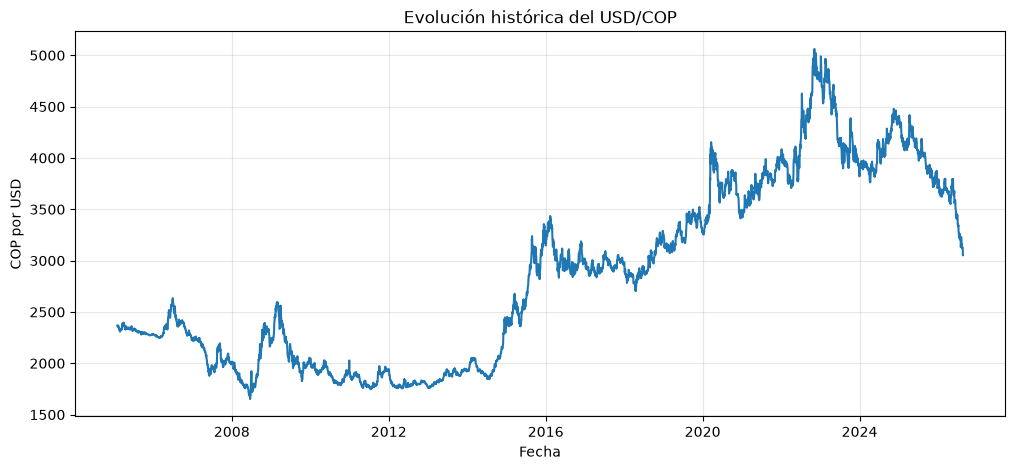

In [24]:
plt.figure(figsize=(12, 5))

plt.plot(
    dataset["date"],
    dataset["usdcop"]
)

plt.title("Evolución histórica del USD/COP")
plt.xlabel("Fecha")
plt.ylabel("COP por USD")
plt.grid(alpha=0.3)

plt.show()

### 11.2 Evolución histórica del USD/COP

La TRM alcanza su mínimo de 1.652,41 COP/USD el 19 de junio de 2008 y su máximo de 5.061,21 el 7 de noviembre de 2022. La trayectoria no es uniforme: combina periodos de apreciación y depreciación del peso con cambios persistentes en el nivel de la tasa.

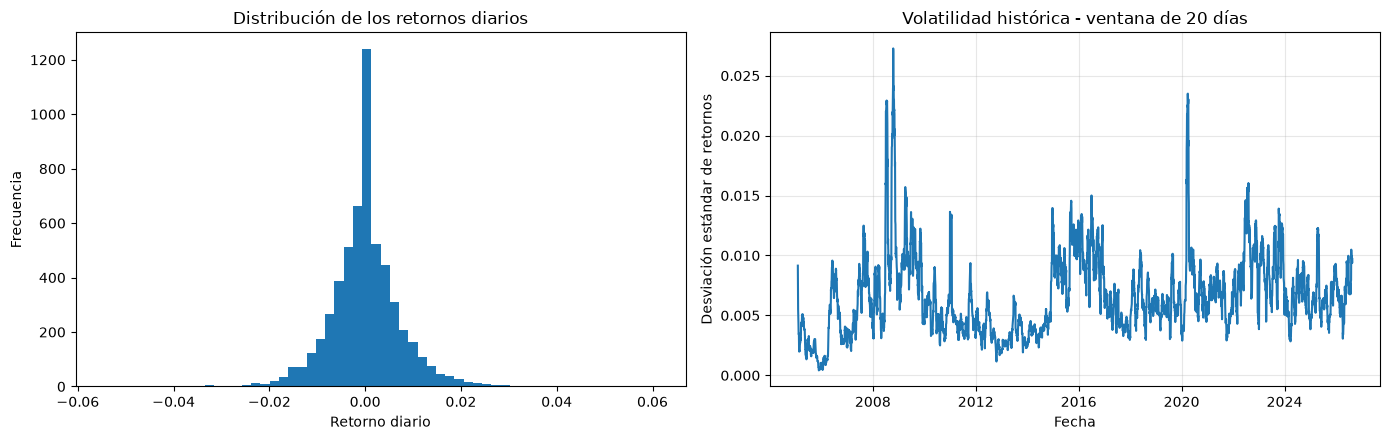

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].hist(dataset["usdcop_ret_1d"], bins=60)
axes[0].set_title("Distribución de los retornos diarios")
axes[0].set_xlabel("Retorno diario")
axes[0].set_ylabel("Frecuencia")

axes[1].plot(dataset["date"], dataset["usdcop_vol_20d"])
axes[1].set_title("Volatilidad histórica - ventana de 20 días")
axes[1].set_xlabel("Fecha")
axes[1].set_ylabel("Desviación estándar de retornos")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 11.3 Retornos y volatilidad

El retorno diario promedio es cercano a cero y la mitad de las observaciones queda entre -0,36 % y 0,35 %. La volatilidad de 20 días cambia a lo largo del tiempo y alcanza su máximo de 2,73 % el 16 de octubre de 2008, lo que evidencia periodos de distinta intensidad en el mercado cambiario.

,frecuencia,porcentaje
target_5d,,
0,2901,51.5825
1,2723,48.4175


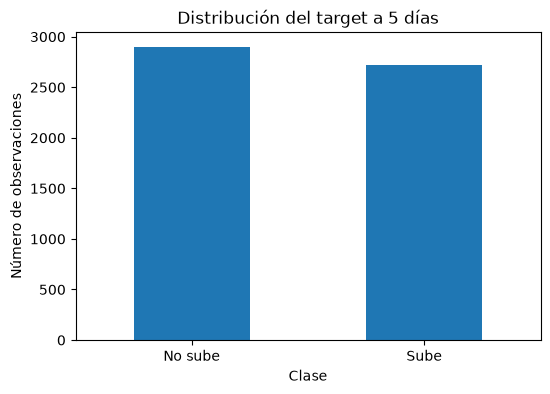

In [26]:
target_distribution = dataset["target_5d"].value_counts().sort_index()
target_percentage = (
    dataset["target_5d"].value_counts(normalize=True).sort_index() * 100
)
target_summary = pd.DataFrame(
    {"frecuencia": target_distribution, "porcentaje": target_percentage}
)
display(target_summary)

plt.figure(figsize=(6, 4))
target_distribution.plot(kind="bar")
plt.title("Distribución del target a 5 días")
plt.xlabel("Clase")
plt.ylabel("Número de observaciones")
plt.xticks([0, 1], ["No sube", "Sube"], rotation=0)
plt.show()

### 11.4 Distribución de la variable objetivo

La clase 0 reúne 2.901 observaciones (51,6 %) y la clase 1 reúne 2.723 (48,4 %). La diferencia es de 178 casos, por lo que el target está relativamente balanceado y no presenta un desbalance marcado en esta primera revisión.

In [27]:
class_comparison = (
    dataset
    .groupby("target_5d")
    [
        [
            "usdcop_ret_5d",
            "usdcop_vol_20d",
            "wti_ret_5d",
            "spy_ret_5d",
            "vix",
            "rate_spread",
        ]
    ]
    .mean()
)

class_comparison

,usdcop_ret_5d,usdcop_vol_20d,wti_ret_5d,spy_ret_5d,vix,rate_spread
target_5d,,,,,,
0,0.0002,0.0067,0.0068,0.0041,19.2540,4.4325
1,0.0007,0.0066,-0.0036,0.0004,18.9812,4.3898


### 11.5 Comparación descriptiva entre clases

Las medias de la volatilidad reciente del USD/COP y del VIX son similares entre las clases. La diferencia más visible aparece en el retorno del WTI a cinco días: promedia 0,68 % cuando el USD/COP no sube y -0,36 % cuando posteriormente sube. Estas diferencias son descriptivas y todavía no demuestran capacidad predictiva.

### 11.6 Conclusiones del análisis descriptivo

El USD/COP presenta cambios amplios de nivel, retornos diarios generalmente pequeños y episodios puntuales de movimientos y volatilidad elevados. El target conserva proporciones cercanas entre sus dos clases, mientras que las diferencias promedio entre grupos son modestas. Estos hallazgos justifican explorar asociaciones conjuntas sin afirmar que la dirección futura ya pueda predecirse.

## 12. Análisis multivariado

El análisis multivariado permite explorar relaciones entre las variables antes
de construir modelos predictivos.

En esta etapa se examinan principalmente las correlaciones entre predictores y
su asociación con la variable objetivo.

El propósito no es establecer causalidad, sino identificar patrones,
redundancias y relaciones potencialmente útiles para el modelado.

,usdcop_ret_1d,usdcop_ret_5d,usdcop_ret_20d,usdcop_vol_20d,usdcop_ma_gap,wti_ret_5d,spy_ret_5d,vix,vix_change_5d,fed_rate,col_rate,us10y,rate_spread,target_5d
usdcop_ret_1d,1.0000,0.4600,0.2250,0.0070,0.3910,-0.1340,-0.1930,0.0600,0.1920,-0.0240,-0.0210,-0.0260,-0.0090,0.0210
usdcop_ret_5d,0.4600,1.0000,0.5060,0.0500,0.7740,-0.1810,-0.3000,0.1210,0.2550,-0.0500,-0.0410,-0.0490,-0.0140,0.0130
usdcop_ret_20d,0.2250,0.5060,1.0000,0.2450,0.8590,-0.1100,-0.1650,0.2100,0.1060,-0.1020,-0.0740,-0.1000,-0.0130,0.0320
usdcop_vol_20d,0.0070,0.0500,0.2450,1.0000,0.1550,-0.0600,-0.0430,0.4880,-0.0060,-0.0370,0.2600,-0.0430,0.4280,-0.0060
usdcop_ma_gap,0.3910,0.7740,0.8590,0.1550,1.0000,-0.1640,-0.2470,0.1830,0.1880,-0.0860,-0.0680,-0.0840,-0.0200,0.0340
wti_ret_5d,-0.1340,-0.1810,-0.1100,-0.0600,-0.1640,1.0000,0.2110,-0.1160,-0.1670,-0.0000,-0.0170,0.0070,-0.0250,-0.0710
spy_ret_5d,-0.1930,-0.3000,-0.1650,-0.0430,-0.2470,0.2110,1.0000,-0.2760,-0.7240,-0.0030,-0.0270,-0.0180,-0.0370,-0.0780
vix,0.0600,0.1210,0.2100,0.4880,0.1830,-0.1160,-0.2760,1.0000,0.2190,-0.2390,0.0200,-0.1500,0.2600,-0.0160
vix_change_5d,0.1920,0.2550,0.1060,-0.0060,0.1880,-0.1670,-0.7240,0.2190,1.0000,0.0070,-0.0070,-0.0070,-0.0170,0.0550
fed_rate,-0.0240,-0.0500,-0.1020,-0.0370,-0.0860,-0.0000,-0.0030,-0.2390,0.0070,1.0000,0.7580,0.7980,0.1790,-0.0770


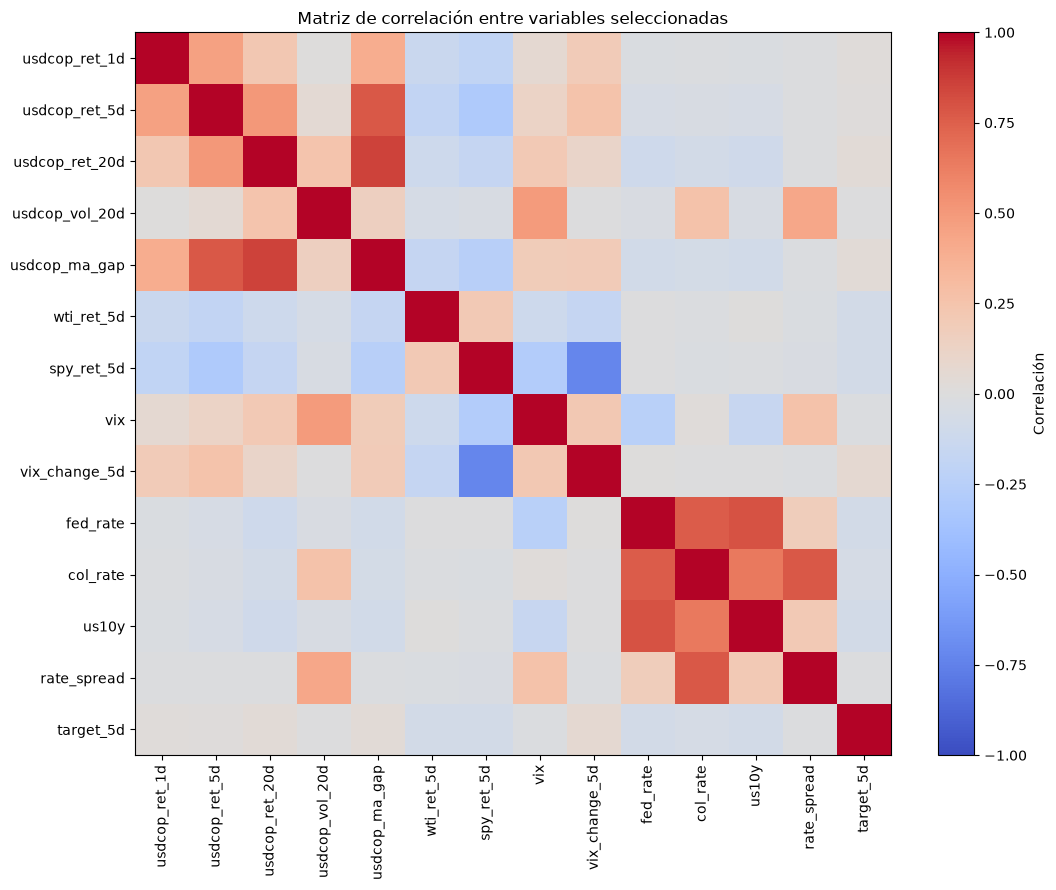

In [28]:
correlation_columns = [
    "usdcop_ret_1d",
    "usdcop_ret_5d",
    "usdcop_ret_20d",
    "usdcop_vol_20d",
    "usdcop_ma_gap",
    "wti_ret_5d",
    "spy_ret_5d",
    "vix",
    "vix_change_5d",
    "fed_rate",
    "col_rate",
    "us10y",
    "rate_spread",
    "target_5d",
]

correlation_matrix = dataset[correlation_columns].corr()
display(correlation_matrix.round(3))

plt.figure(figsize=(11, 9))
plt.imshow(correlation_matrix, aspect="auto", vmin=-1, vmax=1, cmap="coolwarm")
plt.colorbar(label="Correlación")
plt.xticks(range(len(correlation_columns)), correlation_columns, rotation=90)
plt.yticks(range(len(correlation_columns)), correlation_columns)
plt.title("Matriz de correlación entre variables seleccionadas")
plt.tight_layout()
plt.show()

### 12.1 Correlación entre predictores

Las asociaciones más altas aparecen entre variables relacionadas: el retorno USD/COP de 20 días y la distancia a su media móvil (0,859), la EFFR y el Treasury 10Y (0,798), y la tasa colombiana y el diferencial de tasas (0,777). Esto señala posible información redundante que deberá considerarse en etapas posteriores.

In [29]:
target_correlations = (
    correlation_matrix["target_5d"]
    .drop("target_5d")
    .sort_values(
        key=abs,
        ascending=False
    )
    .to_frame("correlacion_target")
)

target_correlations

,correlacion_target
spy_ret_5d,-0.0776
fed_rate,-0.0770
us10y,-0.0732
wti_ret_5d,-0.0711
col_rate,-0.0562
vix_change_5d,0.0555
usdcop_ma_gap,0.0341
usdcop_ret_20d,0.0325
usdcop_ret_1d,0.0215
vix,-0.0160


### 12.2 Asociación con la variable objetivo

Todas las correlaciones individuales con `target_5d` son débiles: su valor absoluto es inferior a 0,08. Las mayores corresponden al retorno del SPY a cinco días (-0,078), la EFFR (-0,077), el Treasury 10Y (-0,073) y el retorno del WTI a cinco días (-0,071). Una asociación lineal pequeña no descarta que combinaciones de variables aporten información más adelante.

In [30]:
high_correlations = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):

        value = correlation_matrix.iloc[i, j]

        if abs(value) >= 0.70:

            high_correlations.append(
                {
                    "variable_1": correlation_matrix.columns[i],
                    "variable_2": correlation_matrix.columns[j],
                    "correlacion": value,
                }
            )

high_correlations = pd.DataFrame(
    high_correlations
)

high_correlations

,variable_1,variable_2,correlacion
0,usdcop_ret_5d,usdcop_ma_gap,0.7736
1,usdcop_ret_20d,usdcop_ma_gap,0.8586
2,spy_ret_5d,vix_change_5d,-0.7239
3,fed_rate,col_rate,0.7579
4,fed_rate,us10y,0.7979
5,col_rate,rate_spread,0.7773


### 12.3 Correlaciones altas entre predictores

Con un umbral absoluto de 0,70 se identifican seis pares altamente correlacionados, incluidos retornos construidos sobre la misma TRM, SPY frente al cambio del VIX y varios indicadores de tasas. El resultado orienta la revisión futura de redundancia, pero no requiere eliminar variables en esta entrega.

### 12.4 Conclusiones del análisis multivariado

Las correlaciones muestran relaciones claras entre algunos predictores, pero asociaciones individuales débiles con el target. Estos resultados son descriptivos: correlación no implica causalidad y tampoco garantiza capacidad predictiva. Aun así, las asociaciones débiles por separado no descartan que una combinación de variables pueda resultar útil cuando se evalúe posteriormente fuera de muestra.

## 13. Conclusiones de la primera entrega

Se construyó una base integrada de 5.649 fechas de lunes a viernes a partir de siete series financieras y macroeconómicas, y se obtuvo un conjunto final de 5.624 observaciones con target. El análisis muestra cambios importantes en el nivel del USD/COP y periodos de diferente volatilidad.

La variable objetivo está relativamente balanceada, con 51,6 % de casos en los que la TRM no sube y 48,4 % en los que sube a cinco días. Las relaciones lineales individuales con el target son débiles, por lo que estos resultados no permiten afirmar que el USD/COP ya pueda predecirse; sí ofrecen una base reproducible para evaluar modelos estadísticos en la siguiente etapa.

## 14. Trabajo futuro

En la siguiente entrega se realizará una división temporal entre entrenamiento y prueba, se establecerá un baseline y se aplicarán modelos de aprendizaje estadístico. Su desempeño se evaluará fuera de muestra mediante métricas comparables, y también podrá refinarse el calendario para incorporar de forma explícita los festivos pertinentes.